In [12]:
import numpy as np


def compute_alpha_schedule(T=500, s=1e-5, clip_min=0.001):
    """
    Computes the recomputed alpha schedule based on the paper's methodology.
    Identical to the previous correct version.
    """
    t_vals = np.arange(0, T + 1)

    # Raw schedule f(t)
    f_t = 1 - (t_vals / T)**2
    alpha_raw = (1 - 2*s) * f_t + s

    # Recompute with stability clipping
    alpha_recomputed = np.zeros(T + 1)
    current_alpha = 1.0

    for t in range(0, T + 1):
        prev_raw = 1.0 if t == 0 else alpha_raw[t-1]
        curr_raw = alpha_raw[t]

        # Calculate ratio squared and clip
        ratio_sq = (curr_raw / prev_raw)**2
        ratio_sq_clipped = max(ratio_sq, clip_min)

        # Accumulate
        current_alpha = current_alpha * np.sqrt(ratio_sq_clipped)
        alpha_recomputed[t] = current_alpha

    return alpha_recomputed

def get_general_reverse_variance(t, s, alpha_schedule):
    """
    Computes the reverse process variance for the transition z_t -> z_s.
    
    Formula based on Image 2:
    sigma_{t->s} = (sigma_{t|s} * sigma_s) / sigma_t
    
    Args:
        t (int): Current time step.
        s (int): Next time step (target), must be < t.
        alpha_schedule (np.array): Precomputed alpha values.
        
    Returns:
        float: The variance sigma_{t->s}^2.
    """
    if s >= t:
        raise ValueError(f"Target step s ({s}) must be less than current step t ({t})")
    if t >= len(alpha_schedule):
        raise ValueError(f"Step t ({t}) is out of bounds for schedule of length {len(alpha_schedule)}")

    # 1. Retrieve Alphas
    alpha_t = alpha_schedule[t]
    alpha_s = alpha_schedule[s]

    # 2. Compute basic Sigmas (sigma^2 = 1 - alpha^2)
    # Note: The paper defines alpha_t approx 1 -> 0, so sigma adds noise.
    sigma_t_sq = 1 - alpha_t**2
    sigma_s_sq = 1 - alpha_s**2

    # Avoid division by zero if t is very small (though t>s>=0 implies t>=1)
    if sigma_t_sq < 1e-12:
        return 0.0

    # 3. Compute Transition Terms (Eq 2 details)
    # alpha_{t|s} = alpha_t / alpha_s
    alpha_t_given_s = alpha_t / alpha_s

    # sigma_{t|s}^2 = sigma_t^2 - alpha_{t|s}^2 * sigma_s^2
    sigma_t_given_s_sq = sigma_t_sq - (alpha_t_given_s**2 * sigma_s_sq)

    # Handle potential negative zero due to float precision
    sigma_t_given_s_sq = max(sigma_t_given_s_sq, 0.0)

    # 4. Compute Posterior Variance (Eq 4 details)
    # Variance = (sigma_{t|s}^2 * sigma_s^2) / sigma_t^2
    variance = (sigma_t_given_s_sq * sigma_s_sq) / sigma_t_sq

    return variance


In [13]:
def get_variance_list(alphas, T, interval):
    variances = []
    current_t = T
    while current_t > 0:
        target_s = max(current_t - interval, 0)
        var = get_general_reverse_variance(current_t, target_s, alphas)
        variances.append(var)
        current_t = target_s
    return variances


In [14]:
from pathlib import Path

import matplotlib.pyplot as plt


def resample_array(values: np.ndarray, target_length: int) -> np.ndarray:
    if len(values) == target_length:
        return values
    else:
        x_original = np.linspace(0, 1, num=len(values))
        x_target = np.linspace(0, 1, num=target_length)
        return np.interp(x_target, x_original, values)

def plot_curve(values: np.ndarray, x_range: np.ndarray, x_label: str, y_label: str, output_path: Path = None) -> None:
    plt.figure(figsize=(8, 4.5))
    plt.plot(x_range, values, linewidth=2)
    plt.xlabel(x_label)
    plt.ylabel(y_label)
    plt.tight_layout()
    if output_path is not None:
        output_path.parent.mkdir(parents=True, exist_ok=True)
        plt.savefig(output_path, dpi=200)
    # plt.close()

def plot_curves(
    curves: list[tuple[str, np.ndarray]], x_ranges: list[np.ndarray], x_label: str, y_label: str, log_scale: bool = False, output_path: Path = None
) -> None:
    if not curves:
        raise ValueError("No curves provided for plotting.")

    plt.figure(figsize=(8, 4.5))

    for (label, values), x_range in zip(curves, x_ranges):
        plt.plot(x_range, values, linewidth=2, label=label)
    plt.xlabel(x_label)
    plt.ylabel(y_label)
    plt.legend()
    plt.gca().invert_xaxis() # Convention: process goes from T to 0
    plt.tight_layout()
    plt.grid(True, which="both", ls="-", alpha=0.5)
    if log_scale:
        plt.yscale("log")
    if output_path is not None:
        output_path.parent.mkdir(parents=True, exist_ok=True)
        plt.savefig(output_path, dpi=200)
        # also save as svg
        plt.savefig(output_path.with_suffix('.svg'))
    plt.show()
    plt.close()

In [15]:

# --- Example Usage with Custom Interval ---

# 1. Generate Schedule
alphas = compute_alpha_schedule(T=500)

# 2. Compute variances for a "Strided" sampling process
# e.g., t = 500 -> 490 -> 480 ... -> 0 (Step size 10)
interval = 10
variances_list = []
steps_log = []

current_t = 500
while current_t > 0:
    target_s = max(current_t - interval, 0) # Ensure s doesn't go below 0

    var = get_general_reverse_variance(current_t, target_s, alphas)
    variances_list.append(var)
    steps_log.append(f"{current_t}->{target_s}")

    current_t = target_s

# Print first 10 steps of the strided variance
print("Computed Variances for Strided Sampling (first 5 steps):")
for step_desc, val in zip(steps_log[:5], variances_list[:5]):
    print(f"Step {step_desc}: {val:.6e}")

Computed Variances for Strided Sampling (first 5 steps):
Step 500->490: 9.984209e-01
Step 490->480: 7.413923e-01
Step 480->470: 5.422375e-01
Step 470->460: 4.213617e-01
Step 460->450: 3.420014e-01


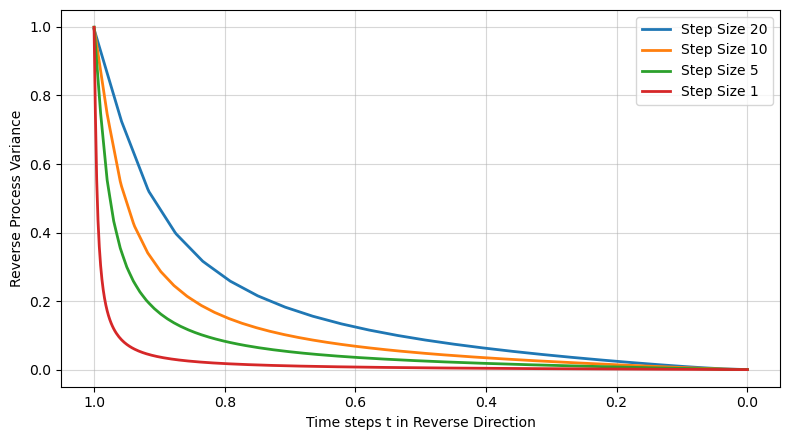

In [16]:
T = 500
alphas = compute_alpha_schedule(T=T)

variances_list_interval_20 = get_variance_list(alphas, T=T, interval=20)
variances_list_interval_10 = get_variance_list(alphas, T=T, interval=10)
variances_list_interval_5 = get_variance_list(alphas, T=T, interval=5)
variances_list_interval_1 = get_variance_list(alphas, T=T, interval=1)

# convert to numpy arrays
array_i20 = np.array(variances_list_interval_20)
array_i10 = np.array(variances_list_interval_10)
array_i5 = np.array(variances_list_interval_5)
array_i1 = np.array(variances_list_interval_1)


# [Version 1] Plot all curves together for comparison, with resampling to common length
plot_curves(
    curves=[
        ("Step Size 20", resample_array(array_i20, T)),
        ("Step Size 10", resample_array(array_i10, T)),
        ("Step Size 5", resample_array(array_i5, T)),
        ("Step Size 1", resample_array(array_i1, T)),
    ],
    x_ranges=[
        np.linspace(1, 0, num=T),
        np.linspace(1, 0, num=T),
        np.linspace(1, 0, num=T),
        np.linspace(1, 0, num=T),
    ],
    x_label="Time steps t in Reverse Direction",
    y_label="Reverse Process Variance",
    output_path=Path("reverse_variance_comparison.png"),
)

# [Version 2] Plot all curves together for comparison
# plot_curves(
#     curves=[
#         ("Interval 20", array_i20),
#         ("Interval 10", array_i10),
#         ("Interval 5", array_i5),
#         ("Interval 1", array_i1),
#     ],
#     x_ranges=[
#         np.linspace(1, 0, num=len(array_i20)),
#         np.linspace(1, 0, num=len(array_i10)),
#         np.linspace(1, 0, num=len(array_i5)),
#         np.linspace(1, 0, num=len(array_i1)),
#     ],
#     x_label="Time steps t in reverse direction",
#     y_label="Reverse Process Variance",
#     output_path=Path("reverse_variance_comparison.png"),
# )



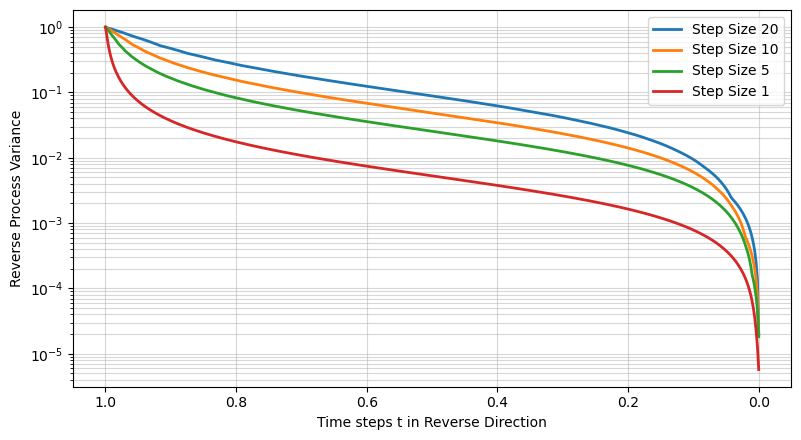

In [17]:
T = 500
alphas = compute_alpha_schedule(T=T)

variances_list_interval_20 = get_variance_list(alphas, T=T, interval=20)
variances_list_interval_10 = get_variance_list(alphas, T=T, interval=10)
variances_list_interval_5 = get_variance_list(alphas, T=T, interval=5)
variances_list_interval_1 = get_variance_list(alphas, T=T, interval=1)

# convert to numpy arrays
array_i20 = np.array(variances_list_interval_20)
array_i10 = np.array(variances_list_interval_10)
array_i5 = np.array(variances_list_interval_5)
array_i1 = np.array(variances_list_interval_1)

# [Version 1] Plot all curves together for comparison, using resampling
plot_curves(
    curves=[
        ("Step Size 20", resample_array(array_i20, T)),
        ("Step Size 10", resample_array(array_i10, T)),
        ("Step Size 5", resample_array(array_i5, T)),
        ("Step Size 1", resample_array(array_i1, T)),
    ],
    x_ranges=[
        np.linspace(1, 0, num=T),
        np.linspace(1, 0, num=T),
        np.linspace(1, 0, num=T),
        np.linspace(1, 0, num=T),
    ],
    x_label="Time steps t in Reverse Direction",
    y_label="Reverse Process Variance",
    log_scale=True,
    output_path=Path("reverse_variance_comparison_logscale.png"),
)

# [Version 2] Plot all curves together for comparison
# plot_curves(
#     curves=[
#         ("Interval 20", array_i20),
#         ("Interval 10", array_i10),
#         ("Interval 5", array_i5),
#         ("Interval 1", array_i1),
#     ],
#     x_ranges=[
#         np.linspace(1, 0, num=len(array_i20)),
#         np.linspace(1, 0, num=len(array_i10)),
#         np.linspace(1, 0, num=len(array_i5)),
#         np.linspace(1, 0, num=len(array_i1)),
#     ],
#     x_label="Time steps t in reverse direction",
#     y_label="Reverse Process Variance",
#     log_scale=True,
#     output_path=Path("reverse_variance_comparison_logscale.png"),
# )

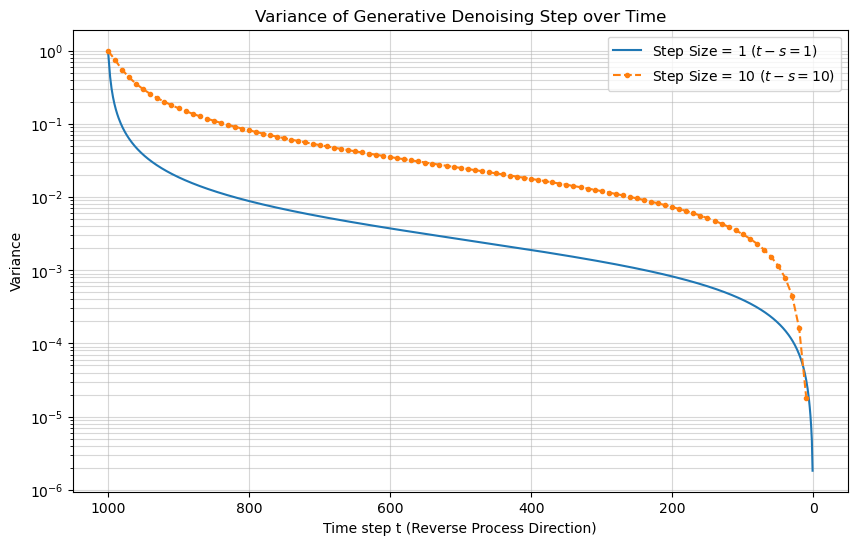

In [ ]:
import matplotlib.pyplot as plt
import numpy as np


def get_alpha_t(t, T=1000, s_prec=1e-5):
    # alpha_t = (1 - 2s) * f(t) + s
    # f(t) = 1 - (t/T)^2
    ft = 1 - (t / T)**2
    return (1 - 2 * s_prec) * ft + s_prec

def get_variance_t_to_s(t, step_size, T=1000, s_prec=1e-5):
    s = t - step_size

    alpha_t = get_alpha_t(t, T, s_prec)
    alpha_s = get_alpha_t(s, T, s_prec)

    sigma_t_sq = 1 - alpha_t**2
    sigma_s_sq = 1 - alpha_s**2

    # Avoid division by zero at t=0, but loop starts at t>=1
    if sigma_t_sq == 0:
        return 0

    alpha_ratio_sq = (alpha_t / alpha_s)**2
    sigma_t_given_s_sq = sigma_t_sq - alpha_ratio_sq * sigma_s_sq

    # Clip small negative values due to precision
    if sigma_t_given_s_sq < 0:
        sigma_t_given_s_sq = 0

    # sigma_{t->s}^2 = sigma_{t|s}^2 * sigma_s^2 / sigma_t^2
    variance = (sigma_t_given_s_sq * sigma_s_sq) / sigma_t_sq
    return variance

# Step size 1
t_range_1 = np.arange(1000, 1, -1) # t goes from 1000 down to 2. s goes 999 to 1.
# Actually let's go down to 1 so s goes to 0? The paper uses s=0 as data.
t_range_1 = np.arange(1000, 0, -1)
variances_1 = [get_variance_t_to_s(t, 1) for t in t_range_1]

# Step size 10
# t goes from 1000, 990, ..., 10. s goes 990, ..., 0.
t_range_10 = np.arange(1000, 9, -10)
variances_10 = [get_variance_t_to_s(t, 10) for t in t_range_10]

plt.figure(figsize=(10, 6))
plt.plot(t_range_1, variances_1, label='Step Size = 1 ($t-s=1$)')
plt.plot(t_range_10, variances_10, label='Step Size = 10 ($t-s=10$)', marker='.', linestyle='--')

plt.xlabel('Time step t (Reverse Process Direction)')
plt.ylabel('Variance')
plt.title('Variance of Generative Denoising Step over Time')
plt.legend()
plt.grid(True, which="both", ls="-", alpha=0.5)
plt.yscale('log') # Log scale to see the behavior across orders of magnitude
plt.gca().invert_xaxis() # Convention: process goes from T to 0
# plt.savefig('variance_comparison_log.png')
plt.show()

# # Linear scale version for comparison/clarity on the high values
# plt.figure(figsize=(10, 6))
# plt.plot(t_range_1, variances_1, label='Step Size = 1 ($t-s=1$)')
# plt.plot(t_range_10, variances_10, label='Step Size = 10 ($t-s=10$)', marker='.', linestyle='--')
# plt.xlabel('Time step t (Reverse Process Direction)')
# plt.ylabel('Variance')
# plt.title('Variance of Generative Denoising Step over Time (Linear Scale)')
# plt.legend()
# plt.grid(True, which="both", ls="-", alpha=0.5)
# plt.gca().invert_xaxis()
# plt.savefig('variance_comparison_linear.png')